In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

2026-05-08 16:42:22.837366: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 16:42:22.856183: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-08 16:42:22.856203: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 16:42:22.856601: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-08 16:42:22.860000: I tensorflow/core/platform/cpu_feature_guar

TensorFlow: 2.15.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-05-08 16:42:23.839697: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-08 16:42:23.915076: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-08 16:42:23.917576: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [2]:
BASE_DIR = "/home/rubix-irat/esp_projects/csi_intrusion_pipeline"

RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
MODEL_DIR = os.path.join(BASE_DIR, "data", "models")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

INTRUSION_FILE = os.path.join(RAW_DIR, "intrusion.csv")
EMPTY_FILE = os.path.join(RAW_DIR, "empty_room.csv")

print(INTRUSION_FILE)
print(EMPTY_FILE)

/home/rubix-irat/esp_projects/csi_intrusion_pipeline/data/raw/intrusion.csv
/home/rubix-irat/esp_projects/csi_intrusion_pipeline/data/raw/empty_room.csv


In [3]:
for f in [INTRUSION_FILE, EMPTY_FILE]:
    print(f)
    print("Exists:", os.path.exists(f))
    if os.path.exists(f):
        print("Size:", os.path.getsize(f) / 1024, "KB")
        with open(f, "r", errors="ignore") as file:
            lines = file.readlines()
        print("Total lines:", len(lines))
        print("CSI lines:", sum("CSI_DATA" in line for line in lines))
        print()

/home/rubix-irat/esp_projects/csi_intrusion_pipeline/data/raw/intrusion.csv
Exists: True
Size: 519.7314453125 KB
Total lines: 1025
CSI lines: 1025

/home/rubix-irat/esp_projects/csi_intrusion_pipeline/data/raw/empty_room.csv
Exists: True
Size: 160.197265625 KB
Total lines: 381
CSI lines: 380



In [4]:
TARGET_SUBCARRIERS = 64

def parse_csi_line(line, target_subcarriers=TARGET_SUBCARRIERS):
    if "CSI_DATA" not in line:
        return None

    try:
        matches = re.findall(r"\[(.*?)\]", line)
        if not matches:
            return None

        values = list(map(int, matches[-1].split()))

        if len(values) < 2:
            return None

        if len(values) % 2 != 0:
            values = values[:-1]

        iq = np.array(values, dtype=np.float32)

        real = iq[::2]
        imag = iq[1::2]

        amplitude = np.sqrt(real**2 + imag**2)
        phase = np.arctan2(imag, real)

        n = min(len(amplitude), target_subcarriers)

        amp_fixed = np.zeros(target_subcarriers, dtype=np.float32)
        phase_fixed = np.zeros(target_subcarriers, dtype=np.float32)

        amp_fixed[:n] = amplitude[:n]
        phase_fixed[:n] = phase[:n]

        amp_fixed = (amp_fixed - np.mean(amp_fixed)) / (np.std(amp_fixed) + 1e-6)
        phase_fixed = (phase_fixed - np.mean(phase_fixed)) / (np.std(phase_fixed) + 1e-6)

        features = np.concatenate([amp_fixed, phase_fixed])

        return features, amp_fixed, phase_fixed

    except:
        return None

In [5]:
def load_csi_file(file_path, label):
    features = []
    amplitudes = []
    phases = []

    with open(file_path, "r", errors="ignore") as f:
        for line in f:
            parsed = parse_csi_line(line)

            if parsed is None:
                continue

            feat, amp, phase = parsed

            features.append(feat)
            amplitudes.append(amp)
            phases.append(phase)

    features = np.array(features, dtype=np.float32)
    amplitudes = np.array(amplitudes, dtype=np.float32)
    phases = np.array(phases, dtype=np.float32)

    labels = np.full(len(features), label)

    return features, amplitudes, phases, labels

In [6]:
intrusion_feat, intrusion_amp, intrusion_phase, intrusion_y = load_csi_file(INTRUSION_FILE, 1)
empty_feat, empty_amp, empty_phase, empty_y = load_csi_file(EMPTY_FILE, 0)

print("Intrusion features:", intrusion_feat.shape)
print("Empty features:", empty_feat.shape)

print("Intrusion amplitude:", intrusion_amp.shape)
print("Empty amplitude:", empty_amp.shape)

Intrusion features: (1025, 128)
Empty features: (0,)
Intrusion amplitude: (1025, 64)
Empty amplitude: (0,)


/home/rubix-irat/esp_projects/csi_realtime_ml/csi_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/rubix-irat/esp_projects/csi_realtime_ml/csi_env/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


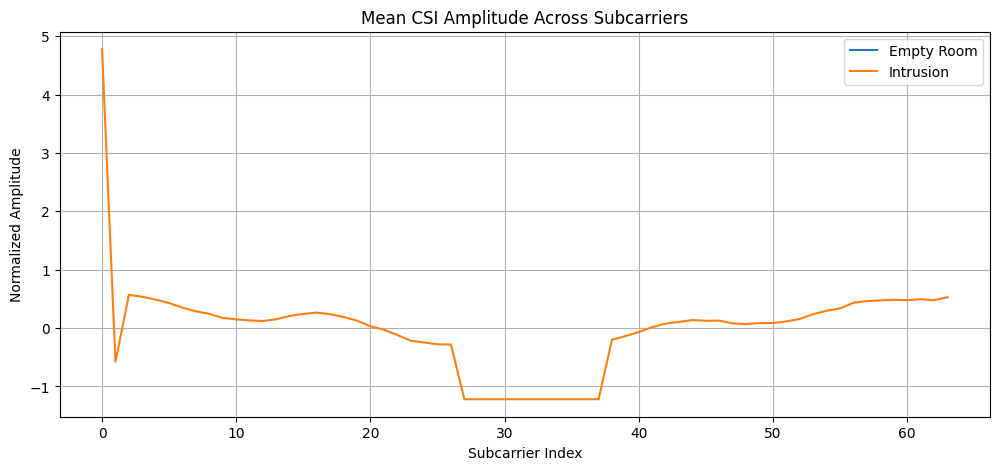

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(np.mean(empty_amp, axis=0), label="Empty Room")
plt.plot(np.mean(intrusion_amp, axis=0), label="Intrusion")
plt.title("Mean CSI Amplitude Across Subcarriers")
plt.xlabel("Subcarrier Index")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True)
plt.show()